# Model comparison

In [5]:
import os
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel
from matplotlib import pyplot as plt
import seaborn as sns
from my_fun import fig_size, add_star_between, get_experiment, filter_drug_sessions
from pathlib import Path
from glue_sessions.glue_sessions import glue_animals, glue_groups
from glmhmm import plot_ll

In [3]:
# Magics
%load_ext autoreload
%autoreload 2

In [ ]:
def iqr_inliers(x):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    return (x >= q1 - 1.5 * iqr) & (x <= q3 + 1.5 * iqr)

In [23]:
print(df_2s_2cov.Nstates.unique(), df_2s_2cov.InputDimensions.unique())
print(df_3s_2cov.Nstates.unique(), df_3s_2cov.InputDimensions.unique())

[2] [2]
[3] [2]


## 2 vs 3 states

### 2 covariates: stim and bias

LL/trial: -0.73 ± 0.41 (LL/trial (bits))
LL/trial: -0.69 ± 0.39 (LL/trial (bits))
t = -8.029, p = 0.000


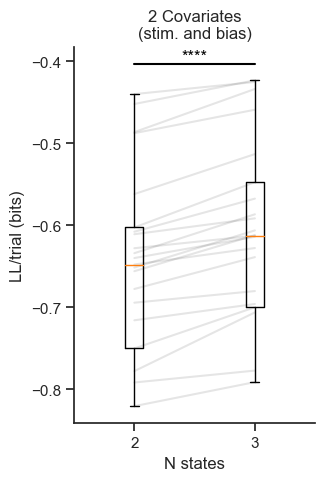

In [22]:
# df_2s_2cov = fit_all(experiments=['2AFC_6'], n_states=2, covariates=['stim_vals', 'bias'], drug=None, save=True)
# df_3s_2cov = fit_all(experiments=['2AFC_6'], n_states=3, covariates=None, drug=None, save=True)

df_2s_2cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='/home/alexis/PycharmProjects/glmhmm/TEST2/2s_2cov')
df_3s_2cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='/home/alexis/PycharmProjects/glmhmm/TEST2/3s_2cov')

figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[1]*2)
plt.figure(figsize=figsize, constrained_layout=True)
ll0 = df_2s_2cov['LogLikelihood'].unique()
n_trials0 = df_2s_2cov.groupby('Subject').size()
ll1 = df_3s_2cov['LogLikelihood'].unique()
n_trials1 = df_3s_2cov.groupby('Subject').size()

ll0 = plot_ll(ll0, n_trials0, to_bits=True, positions=[0])
ll1 = plot_ll(ll1, n_trials1, to_bits=True, positions=[1])
ll0 = np.array(ll0)
ll1 = np.array(ll1)
inliers_0 = iqr_inliers(ll0)
inliers_1 = iqr_inliers(ll1)

# for y0, y1 in zip(ll0, ll1):
#     plt.plot([0, 1], [y0, y1], color='k', alpha=0.1)
for y0, y1 in zip(ll0[inliers_0 & inliers_1], ll1[inliers_0 & inliers_1]):
    plt.plot([0, 1], [y0, y1], color='k', alpha=0.1)

# Paired t-test between states (not needed because sums to 1)
t_stat, p_val = ttest_rel(ll0, ll1)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)

plt.xticks([0, 1],['2', '3'])
plt.xlabel('N states')
plt.title('2 Covariates\n(stim. and bias)')
sns.despine()

### 3 covariates: stim, bias, and action trace

LL/trial: -0.72 ± 0.41 (LL/trial (bits))
LL/trial: -0.69 ± 0.39 (LL/trial (bits))
t = -6.393, p = 0.000


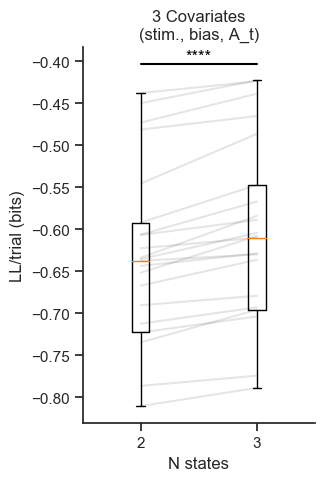

In [24]:
# df_2s_3cov = fit_all(experiments=['2AFC_6'], n_states=2, covariates=None, drug=None, save=True)
# df_3s_3cov = fit_all(experiments=['2AFC_6'], n_states=3, covariates=None, drug=None, save=True)

df_2s_3cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='/home/alexis/PycharmProjects/glmhmm/TEST2/2s_3cov')
df_3s_3cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='/home/alexis/PycharmProjects/glmhmm/TEST2/3s_3cov')

figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[1]*2)
plt.figure(figsize=figsize, constrained_layout=True)
ll0 = df_2s_3cov['LogLikelihood'].unique()
n_trials0 = df_2s_3cov.groupby('Subject').size()
ll1 = df_3s_3cov['LogLikelihood'].unique()
n_trials1 = df_3s_3cov.groupby('Subject').size()

ll0 = plot_ll(ll0, n_trials0, to_bits=True, positions=[0])
ll1 = plot_ll(ll1, n_trials1, to_bits=True, positions=[1])
ll0 = np.array(ll0)
ll1 = np.array(ll1)
inliers_0 = iqr_inliers(ll0)
inliers_1 = iqr_inliers(ll1)

# for y0, y1 in zip(ll0, ll1):
#     plt.plot([0, 1], [y0, y1], color='k', alpha=0.1)
for y0, y1 in zip(ll0[inliers_0 & inliers_1], ll1[inliers_0 & inliers_1]):
    plt.plot([0, 1], [y0, y1], color='k', alpha=0.1)

# Paired t-test between states (not needed because sums to 1)
t_stat, p_val = ttest_rel(ll0, ll1)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)

plt.xticks([0, 1],['2', '3'])
plt.xlabel('N states')
plt.title('3 Covariates\n(stim., bias, A_t)')
sns.despine()

## 2 vs 3 covariates

### 2 states

LL/trial: -0.73 ± 0.41 (LL/trial (bits))
LL/trial: -0.72 ± 0.41 (LL/trial (bits))
t = -4.275, p = 0.000


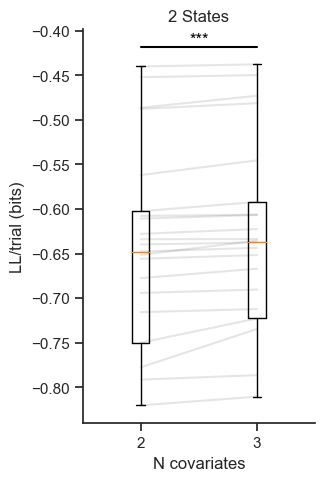

In [25]:
# 2 (stim. and bias) vs 3 (stim, bias and action trace) covariates with 2 states
# df_2s_3cov = fit_all(experiments=[ '2AFC_6'], n_states=2, covariates=['stim_vals', 'bias', 'action_trace'], drug=None, save=True)
# The other pair for the comparison is df_2s_2cov from above

df_2s_3cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='/home/alexis/PycharmProjects/glmhmm/TEST2/2s_3cov')

figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[1]*2)
plt.figure(figsize=figsize, constrained_layout=True)
ll0 = df_2s_2cov['LogLikelihood'].unique()
n_trials0 = df_2s_2cov.groupby('Subject').size()
ll1 = df_2s_3cov['LogLikelihood'].unique()
n_trials1 = df_2s_3cov.groupby('Subject').size()

ll0 = plot_ll(ll0, n_trials0, to_bits=True, positions=[0])
ll1 = plot_ll(ll1, n_trials1, to_bits=True, positions=[1])
ll0 = np.array(ll0)
ll1 = np.array(ll1)
inliers_0 = iqr_inliers(ll0)
inliers_1 = iqr_inliers(ll1)

# for y0, y1 in zip(ll0, ll1):
#     plt.plot([0, 1], [y0, y1], color='k', alpha=0.1)
for y0, y1 in zip(ll0[inliers_0 & inliers_1], ll1[inliers_0 & inliers_1]):
    plt.plot([0, 1], [y0, y1], color='k', alpha=0.1)

# Paired t-test between states (not needed because sums to 1)
t_stat, p_val = ttest_rel(ll0, ll1)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)

plt.xticks([0, 1],['2', '3'])
plt.xlabel('N covariates')
plt.title('2 States')
sns.despine()

### 3 states

LL/trial: -0.69 ± 0.39 (LL/trial (bits))
LL/trial: -0.69 ± 0.39 (LL/trial (bits))
t = -1.503, p = 0.146


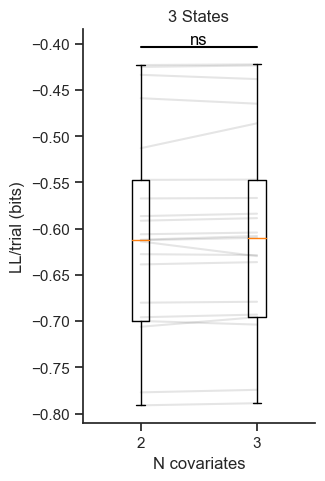

In [26]:
# 2 (stim. and bias) vs 3 (stim, bias and action trace) covariates with 3 states
# df_3s_3cov = fit_all(experiments=[ '2AFC_6'], n_states=3, covariates=['stim_vals', 'bias', 'action_trace'], drug=None, save=True)
# The other pair for the comparison is df_3s_2cov from above

df_3s_3cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='/home/alexis/PycharmProjects/glmhmm/TEST2/3s_3cov')

figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[1]*2)
plt.figure(figsize=figsize, constrained_layout=True)
ll0 = df_3s_2cov['LogLikelihood'].unique()
n_trials0 = df_3s_2cov.groupby('Subject').size()
ll1 = df_3s_3cov['LogLikelihood'].unique()
n_trials1 = df_3s_3cov.groupby('Subject').size()

ll0 = plot_ll(ll0, n_trials0, to_bits=True, positions=[0])
ll1 = plot_ll(ll1, n_trials1, to_bits=True, positions=[1])
ll0 = np.array(ll0)
ll1 = np.array(ll1)
inliers_0 = iqr_inliers(ll0)
inliers_1 = iqr_inliers(ll1)

# for y0, y1 in zip(ll0, ll1):
#     plt.plot([0, 1], [y0, y1], color='k', alpha=0.1)
for y0, y1 in zip(ll0[inliers_0 & inliers_1], ll1[inliers_0 & inliers_1]):
    plt.plot([0, 1], [y0, y1], color='k', alpha=0.1)

# Paired t-test between states (not needed because sums to 1)
t_stat, p_val = ttest_rel(ll0, ll1)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)

plt.xticks([0, 1],['2', '3'])
plt.xlabel('N covariates')
plt.title('3 States')
sns.despine()

# Ocuupancy

In [ ]:
occ_2s_2cov_saline = plot_occupancy_boxplot(df_2s_2cov[df_2s_2cov.Drug==0], figsize=figsize)
occ_2s_2cov_drug = plot_occupancy_boxplot(df_2s_2cov[df_2s_2cov.Drug==1], figsize=figsize)
occ_2s_2cov_saline['Drug'] = 0
occ_2s_2cov_drug['Drug'] = 1
occ_2s_2cov_comparison = pd.concat([occ_2s_2cov_saline, occ_2s_2cov_drug], ignore_index=True)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=occ_2s_2cov_comparison, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
# Paired t-test between states (not needed because sums to 1)
engaged_saline = occ_2s_2cov_comparison[occ_2s_2cov_comparison['Drug'] == 0]['Engaged']
engaged_drug = occ_2s_2cov_comparison[occ_2s_2cov_comparison['Drug'] == 1]['Engaged']
t_stat, p_val = ttest_rel(engaged_saline, engaged_drug)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
plt.title('2 states\n(2 cov.: stim., bias)')



occ_2s_3cov_saline = plot_occupancy_boxplot(df_2s_3cov[df_2s_3cov.Drug==0], figsize=figsize)
occ_2s_3cov_drug = plot_occupancy_boxplot(df_2s_3cov[df_2s_3cov.Drug==1], figsize=figsize)
occ_2s_3cov_saline['Drug'] = 0
occ_2s_3cov_drug['Drug'] = 1
occ_2s_3cov_comparison = pd.concat([occ_2s_3cov_saline, occ_2s_3cov_drug], ignore_index=True)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=occ_2s_3cov_comparison, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
# Paired t-test between states (not needed because sums to 1)
engaged_saline = occ_2s_3cov_comparison[occ_2s_3cov_comparison['Drug'] == 0]['Engaged']
engaged_drug = occ_2s_3cov_comparison[occ_2s_3cov_comparison['Drug'] == 1]['Engaged']
t_stat, p_val = ttest_rel(engaged_saline, engaged_drug)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
plt.title('2 states\n(3 cov.: stim., bias, At)')



occ_3s_2cov_saline = plot_occupancy_boxplot(df_3s_2cov[df_3s_2cov.Drug==0], figsize=figsize)
occ_3s_2cov_drug = plot_occupancy_boxplot(df_3s_2cov[df_3s_2cov.Drug==1], figsize=figsize)
occ_3s_2cov_saline['Drug'] = 0
occ_3s_2cov_drug['Drug'] = 1
occ_3s_2cov_comparison = pd.concat([occ_3s_2cov_saline, occ_3s_2cov_drug], ignore_index=True)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=occ_3s_2cov_comparison, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
# Paired t-test between states (not needed because sums to 1)
engaged_saline = occ_3s_2cov_comparison[occ_3s_2cov_comparison['Drug'] == 0]['Engaged']
engaged_drug = occ_3s_2cov_comparison[occ_3s_2cov_comparison['Drug'] == 1]['Engaged']
t_stat, p_val = ttest_rel(engaged_saline, engaged_drug)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
plt.title('3 states\n(2 cov.: stim., bias)')



occ_3s_3cov_saline = plot_occupancy_boxplot(df_3s_3cov[df_3s_3cov.Drug==0], figsize=figsize)
occ_3s_3cov_drug = plot_occupancy_boxplot(df_3s_3cov[df_3s_3cov.Drug==1], figsize=figsize)
occ_3s_3cov_saline['Drug'] = 0
occ_3s_3cov_drug['Drug'] = 1
occ_3s_3cov_comparison = pd.concat([occ_3s_3cov_saline, occ_3s_3cov_drug], ignore_index=True)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=occ_3s_3cov_comparison, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
# Paired t-test between states (not needed because sums to 1)
engaged_saline = occ_3s_3cov_comparison[occ_3s_3cov_comparison['Drug'] == 0]['Engaged']
engaged_drug = occ_3s_3cov_comparison[occ_3s_3cov_comparison['Drug'] == 1]['Engaged']
t_stat, p_val = ttest_rel(engaged_saline, engaged_drug)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
plt.title('3 states\n(3 cov.: stim., bias, At)')